# Análise de desempenho: Serial vs. Paralelo

Usar o arquivo **`comparacao_geral_maior.csv`** para gerar:

- tabela consolidada com tempos;
- tabela pivô por tamanho e método;
- gráfico de tempo de execução;
- gráfico de speedup;
- gráfico de eficiência.

In [12]:
pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
base_dir = Path("comparacao_serial_paralelo")

arquivo_serial = base_dir / "comparacao_serial.csv"
arquivo_paralelo = base_dir / "comparacao_paralelo.csv"

df_serial = pd.read_csv(arquivo_serial)
df_paralelo = pd.read_csv(arquivo_paralelo)

print("Arquivo serial:", arquivo_serial)
print("Arquivo paralelo:", arquivo_paralelo)

,n,m,tempo_execucao,metodo,tamanho
0,100,200,0.080648,Serial,100 x 200
1,200,400,0.617857,Serial,200 x 400
2,300,600,2.587646,Serial,300 x 600
3,400,800,6.669363,Serial,400 x 800
4,500,1000,13.928832,Serial,500 x 1000
5,600,1200,24.703132,Serial,600 x 1200
6,700,1400,45.822836,Serial,700 x 1400
7,800,1600,53.002017,Serial,800 x 1600
8,900,1800,94.768750,Serial,900 x 1800
9,1000,2000,143.757171,Serial,1000 x 2000


In [ ]:
df_serial["metodo"] = "Serial"
df_paralelo["metodo"] = "Paralelo"

df = pd.concat([df_serial, df_paralelo], ignore_index=True)
df["tamanho"] = df["n"].astype(str) + " x " + df["m"].astype(str)

df

metodo,tamanho,Paralelo,Serial
0,100 x 200,1.088326,0.080648
1,1000 x 2000,33.437015,143.757171
2,200 x 400,0.619637,0.617857
3,300 x 600,1.134430,2.587646
4,400 x 800,2.291678,6.669363
5,500 x 1000,4.912635,13.928832
6,600 x 1200,7.540069,24.703132
7,700 x 1400,12.714352,45.822836
8,800 x 1600,26.264682,53.002017
9,900 x 1800,29.882354,94.768750


In [ ]:
tabela_tempo = df.pivot(index="tamanho", columns="metodo", values="tempo_execucao").reset_index()
tabela_tempo

metodo,tamanho,Paralelo,Serial,speedup_serial_vs_paralelo
0,100 x 200,1.088326,0.080648,0.074103
1,1000 x 2000,33.437015,143.757171,4.299342
2,200 x 400,0.619637,0.617857,0.997127
3,300 x 600,1.134430,2.587646,2.281010
4,400 x 800,2.291678,6.669363,2.910253
5,500 x 1000,4.912635,13.928832,2.835308
6,600 x 1200,7.540069,24.703132,3.276247
7,700 x 1400,12.714352,45.822836,3.604024
8,800 x 1600,26.264682,53.002017,2.017996
9,900 x 1800,29.882354,94.768750,3.171395


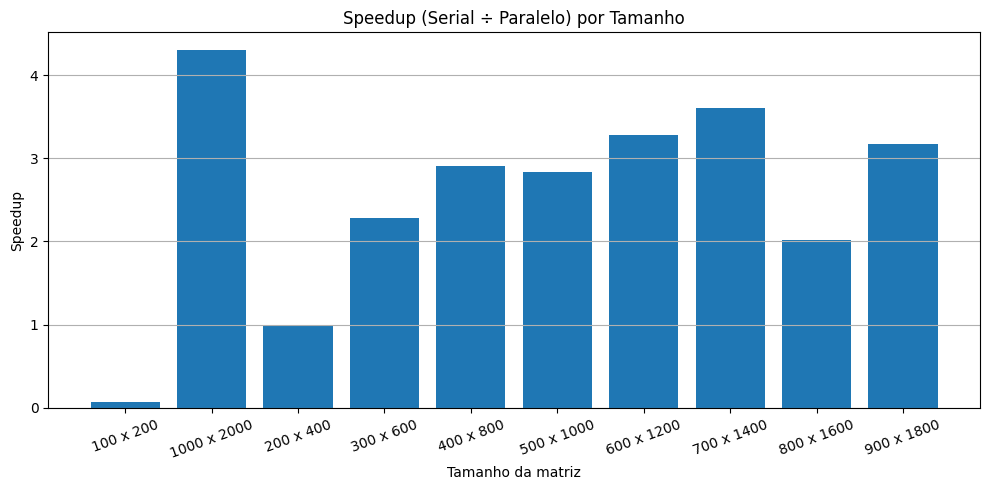

In [ ]:
df_speedup = tabela_tempo.copy()
df_speedup["speedup_serial_vs_paralelo"] = df_speedup["Serial"] / df_speedup["Paralelo"]

df_speedup

In [ ]:
plt.figure(figsize=(10, 5))

for metodo in df["metodo"].unique():
    base = df[df["metodo"] == metodo]
    plt.plot(base["tamanho"], base["tempo_execucao"], marker="o", label=metodo)

plt.title("Comparação de Tempo: Serial vs Paralelo")
plt.xlabel("Tamanho da matriz")
plt.ylabel("Tempo de execução (s)")
plt.legend()
plt.grid(True, axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

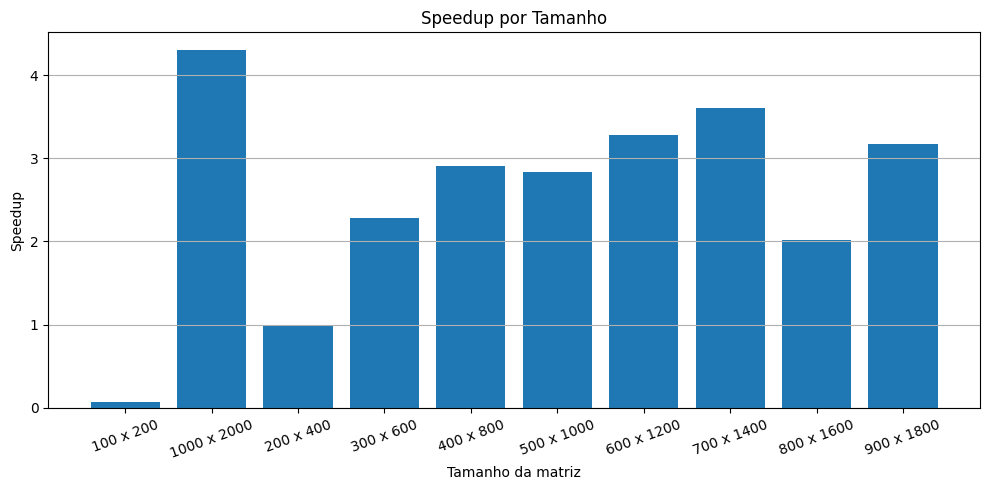

In [ ]:
plt.figure(figsize=(10, 5))
barras = plt.bar(df_speedup["tamanho"], df_speedup["speedup_serial_vs_paralelo"])

plt.title("Speedup (Tempo Serial / Tempo Paralelo) por Tamanho")
plt.xlabel("Tamanho da matriz")
plt.ylabel("Speedup")
plt.xticks(rotation=20)
plt.grid(True, axis="y")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
tabela_apresentacao = df_speedup[["tamanho", "Serial", "Paralelo", "speedup_serial_vs_paralelo"]].copy()
tabela_apresentacao = tabela_apresentacao.rename(columns={
    "Serial": "tempo_serial",
    "Paralelo": "tempo_paralelo",
    "speedup_serial_vs_paralelo": "speedup"
})

tabela_apresentacao

KeyError: 'Column not found: tempo_segundos'

In [ ]:
saida_resumo = base_dir / "tabela_apresentacao.csv"
tabela_apresentacao.to_csv(saida_resumo, index=False, encoding="utf-8-sig")

print("Tabela salva em:", saida_resumo)